In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [3]:
# Load Google stock price dataset

data = pd.read_csv("Google_Stock_Price_Train.csv")

In [4]:
# Show first 5 rows

print(data.head())

       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800


In [5]:
# Take only Open column

dataset = data[['Open']]

In [6]:
# Scale values between 0 and 1

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(dataset)

In [7]:
# Create x_train and y_train

x_train = []
y_train = []

# Use previous 60 days to predict next day

for i in range(60, len(scaled_data)):

    x_train.append(scaled_data[i-60:i, 0])

    y_train.append(scaled_data[i, 0])

In [8]:
# Convert lists into arrays

x_train = np.array(x_train)
y_train = np.array(y_train)

In [ ]:
# Reshape into 3D format

x_train = np.reshape(x_train,(x_train.shape[0], x_train.shape[1], 1))

In [ ]:
# Create Sequential model

model = Sequential()

# Add RNN layer
model.add(SimpleRNN(units=50,activation='tanh',input_shape=(x_train.shape[1], 1)))

# Output layer
model.add(Dense(1))

c:\Users\Sumit\desktop\anaconda\envs\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Compile model

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [12]:
# Train the model

model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0610
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.8508e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.5528e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3796e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.3899e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.2915e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.0571e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.8770e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.2426e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.6150e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.4404e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

In [13]:
# Load test dataset

test_data = pd.read_csv("Google_Stock_Price_Test.csv")

In [ ]:
# Combine train and test data

total_data = pd.concat(
    (data['Open'], test_data['Open']),
    axis=0
)

# Take required inputs
inputs = total_data[len(total_data) - len(test_data) - 60:].values

# Reshape data
inputs = inputs.reshape(-1,1)

# Normalize data
inputs = scaler.transform(inputs)

c:\Users\Sumit\desktop\anaconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [15]:
# Prepare testing sequences

x_test = []

for i in range(60, len(inputs)):

    x_test.append(inputs[i-60:i, 0])

# Convert to array
x_test = np.array(x_test)

# Reshape for RNN
x_test = np.reshape(
    x_test,
    (x_test.shape[0], x_test.shape[1], 1)
)

In [23]:
# Predict stock prices

predicted_price = model.predict(x_test)

# Convert back to original values
predicted_price = scaler.inverse_transform(predicted_price)
print(predicted_price[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
[[785.90393]
 [783.822  ]
 [782.2418 ]
 [785.5965 ]
 [787.2487 ]]


In [21]:
# Actual stock prices
# Actual stock prices

real_price = test_data[['Open']]

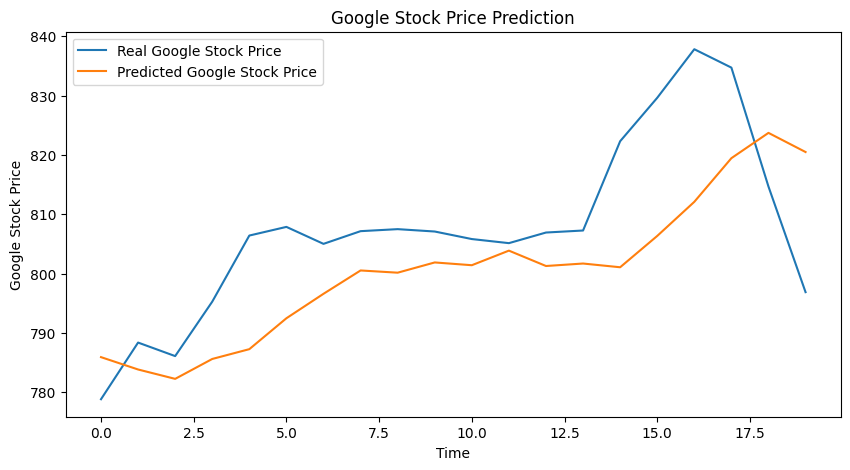

In [22]:
# Plot actual vs predicted prices

plt.figure(figsize=(10,5))

# Real prices
plt.plot(real_price, label='Real Google Stock Price')

# Predicted prices
plt.plot(predicted_price, label='Predicted Google Stock Price')

# Graph title
plt.title('Google Stock Price Prediction')

# Axis labels
plt.xlabel('Time')
plt.ylabel('Google Stock Price')

# Show legend
plt.legend()

# Display graph
plt.show()